In [1]:
# EXPERIMENT 5
# Text Document Classification using Deep Learning

import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GlobalAveragePooling1D
from tensorflow.keras.layers import Dense, Dropout
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score

# ---------------------------------------------------------
# 1. Dataset
# ---------------------------------------------------------

texts = [
    # Sports
    "India won the cricket match",
    "The football team won the championship",
    "The player scored a goal in the match",
    "The cricket team prepared for the tournament",
    "The coach announced the final team",

    # Technology
    "Artificial intelligence is changing the world",
    "Machine learning is used in many applications",
    "The new smartphone has advanced technology",
    "Researchers developed a new deep learning model",
    "The software company launched a new product",

    # Politics
    "The government announced a new policy",
    "The election campaign started today",
    "The parliament passed a new bill",
    "The minister addressed the public meeting",
    "Political leaders discussed the new policy",

    # Business
    "The company reported increased profits",
    "The stock market showed strong growth",
    "The bank announced a new financial service",
    "Business investments increased this year",
    "The company opened a new branch"
]

labels = [
    "Sports", "Sports", "Sports", "Sports", "Sports",
    "Technology", "Technology", "Technology", "Technology", "Technology",
    "Politics", "Politics", "Politics", "Politics", "Politics",
    "Business", "Business", "Business", "Business", "Business"
]

# ---------------------------------------------------------
# 2. Encode Labels
# ---------------------------------------------------------

label_encoder = LabelEncoder()

y = label_encoder.fit_transform(labels)

print("Classes:")
print(label_encoder.classes_)

# ---------------------------------------------------------
# 3. Tokenization
# ---------------------------------------------------------

vocab_size = 5000

tokenizer = Tokenizer(
    num_words=vocab_size,
    oov_token="<OOV>"
)

tokenizer.fit_on_texts(texts)

sequences = tokenizer.texts_to_sequences(texts)

print("\nOriginal Text:")
print(texts[0])

print("\nTokenized Text:")
print(sequences[0])

# ---------------------------------------------------------
# 4. Padding
# ---------------------------------------------------------

max_length = 12

X = pad_sequences(
    sequences,
    maxlen=max_length,
    padding="post"
)

print("\nPadded Data:")
print(X)

print("\nInput Shape:", X.shape)

# ---------------------------------------------------------
# 5. Train-Test Split
# ---------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print("\nTraining Samples:", len(X_train))
print("Testing Samples:", len(X_test))

# ---------------------------------------------------------
# 6. Build Deep Learning Model
# ---------------------------------------------------------

embedding_dim = 64
num_classes = len(label_encoder.classes_)

model = Sequential([

    # Convert word indices into dense vectors
    Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim
    ),

    # Convert sequence into a fixed-size vector
    GlobalAveragePooling1D(),

    # Hidden layer
    Dense(64, activation="relu"),

    # Prevent overfitting
    Dropout(0.3),

    # Output layer
    Dense(num_classes, activation="softmax")
])

# ---------------------------------------------------------
# 7. Compile Model
# ---------------------------------------------------------

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("\nModel Summary:")
model.summary()

# ---------------------------------------------------------
# 8. Train Model
# ---------------------------------------------------------

history = model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=4,
    validation_split=0.2,
    verbose=1
)

# ---------------------------------------------------------
# 9. Evaluate Model
# ---------------------------------------------------------

loss, accuracy = model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print("\n--------------------------------")
print("MODEL PERFORMANCE")
print("--------------------------------")

print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

# ---------------------------------------------------------
# 10. Predictions
# ---------------------------------------------------------

y_probability = model.predict(X_test)

y_pred = np.argmax(
    y_probability,
    axis=1
)

print("\nActual Labels:")
print(label_encoder.inverse_transform(y_test))

print("\nPredicted Labels:")
print(label_encoder.inverse_transform(y_pred))

# ---------------------------------------------------------
# 11. Classification Report
# ---------------------------------------------------------

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=label_encoder.classes_,
        zero_division=0
    )
)

# ---------------------------------------------------------
# 12. Predict a New Document
# ---------------------------------------------------------

new_document = [
    "The new artificial intelligence software uses machine learning"
]

new_sequence = tokenizer.texts_to_sequences(
    new_document
)

new_padded = pad_sequences(
    new_sequence,
    maxlen=max_length,
    padding="post"
)

prediction = model.predict(new_padded)

predicted_class = np.argmax(
    prediction,
    axis=1
)

predicted_label = label_encoder.inverse_transform(
    predicted_class
)

print("\n--------------------------------")
print("NEW DOCUMENT CLASSIFICATION")
print("--------------------------------")

print("Document:")
print(new_document[0])

print("\nPredicted Category:")
print(predicted_label[0])

Classes:
['Business' 'Politics' 'Sports' 'Technology']

Original Text:
India won the cricket match

Tokenized Text:
[16, 8, 2, 9, 10]

Padded Data:
[[16  8  2  9 10  0  0  0  0  0  0  0]
 [ 2 17  5  8  2 18  0  0  0  0  0  0]
 [ 2 19 20  4 21 11  2 10  0  0  0  0]
 [ 2  9  5 22 23  2 24  0  0  0  0  0]
 [ 2 25  6  2 26  5  0  0  0  0  0  0]
 [27 28 12 29  2 30  0  0  0  0  0  0]
 [31 13 12 32 11 33 34  0  0  0  0  0]
 [ 2  3 35 36 37 38  0  0  0  0  0  0]
 [39 40  4  3 41 13 42  0  0  0  0  0]
 [ 2 43  7 44  4  3 45  0  0  0  0  0]
 [ 2 46  6  4  3 14  0  0  0  0  0  0]
 [ 2 47 48 49 50  0  0  0  0  0  0  0]
 [ 2 51 52  4  3 53  0  0  0  0  0  0]
 [ 2 54 55  2 56 57  0  0  0  0  0  0]
 [58 59 60  2  3 14  0  0  0  0  0  0]
 [ 2  7 61 15 62  0  0  0  0  0  0  0]
 [ 2 63 64 65 66 67  0  0  0  0  0  0]
 [ 2 68  6  4  3 69 70  0  0  0  0  0]
 [71 72 15 73 74  0  0  0  0  0  0  0]
 [ 2  7 75  4  3 76  0  0  0  0  0  0]]

Input Shape: (20, 12)

Training Samples: 15
Testing Samples: 5

Model 

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ ?                      │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 491ms/step - accuracy: 0.3333 - loss: 1.3855 - val_accuracy: 0.0000e+00 - val_loss: 1.3946
Epoch 2/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 213ms/step - accuracy: 0.2500 - loss: 1.3815 - val_accuracy: 0.0000e+00 - val_loss: 1.3990
Epoch 3/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step - accuracy: 0.4167 - loss: 1.3792 - val_accuracy: 0.0000e+00 - val_loss: 1.4039
Epoch 4/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.3333 - loss: 1.3725 - val_accuracy: 0.0000e+00 - val_loss: 1.4095
Epoch 5/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.4167 - loss: 1.3667 - val_accuracy: 0.0000e+00 - val_loss: 1.4153
Epoch 6/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.3333 - loss: 1.3602 - val_accuracy: 0.0000e+00 - val_loss: 1.4221
Epoch 7/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.4167 - loss: 1.3516 - val_accuracy: 0.0000e+00 - val_loss: 1.4307
Epoch 8/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.3333 - loss: 1.3524 - val_accur

20 NEWSGROUPS DATASET
Number of Training Documents: 2239
Number of Testing Documents: 1490

Categories:
0 : comp.graphics
1 : rec.sport.baseball
2 : sci.space
3 : talk.politics.misc

SAMPLE DOCUMENT
I thought that was Sandy Koufax.

Category: rec.sport.baseball

TOKENIZATION
Original Text:
I thought that was Sandy Koufax.

Tokenized Text:
[10, 370, 9, 23, 5312, 3281]

PADDING
Training Data Shape: (2239, 200)
Testing Data Shape: (1490, 200)

MODEL SUMMARY


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_1      │ ?                      │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)


MODEL TRAINING
Epoch 1/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.2987 - loss: 1.3712 - val_accuracy: 0.3259 - val_loss: 1.3464
Epoch 2/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.3451 - loss: 1.3411 - val_accuracy: 0.3862 - val_loss: 1.3018
Epoch 3/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.4344 - loss: 1.2784 - val_accuracy: 0.5424 - val_loss: 1.2140
Epoch 4/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.5840 - loss: 1.1453 - val_accuracy: 0.5714 - val_loss: 1.0827
Epoch 5/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.6968 - loss: 0.9513 - val_accuracy: 0.5647 - val_loss: 0.9824
Epoch 6/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.7409 - loss: 0.7886 - val_accuracy: 0.8192 - val_loss: 0.7219
Epoch 7/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.7655 - loss: 0.6585 - val_accuracy: 0.6942 - val_loss: 0.7457
Epoch 8/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.8096 - loss: 0.5591 - val_accu

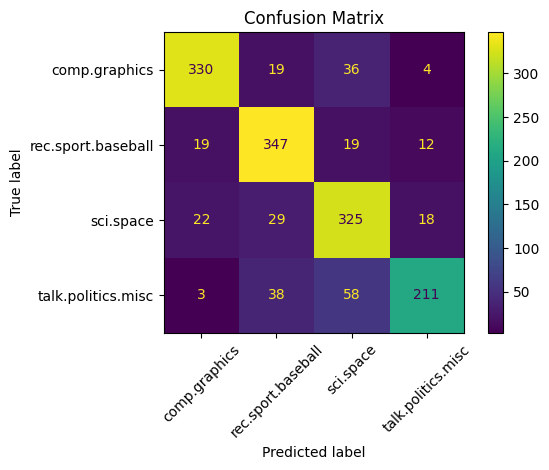

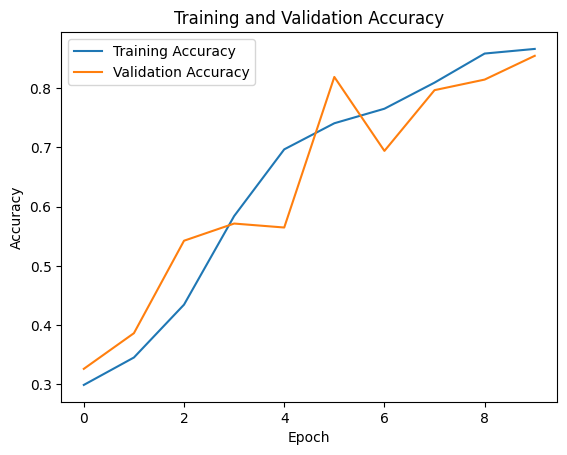

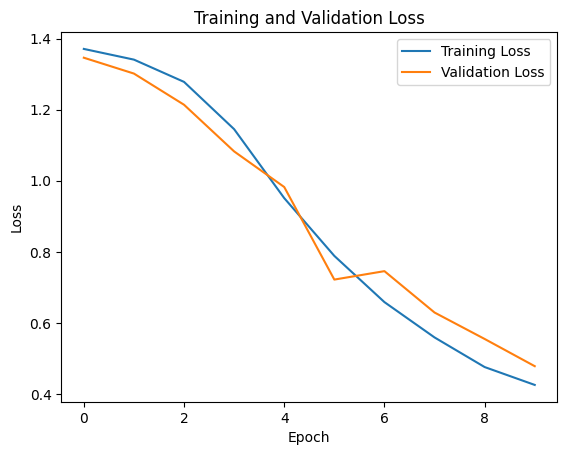

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step

NEW DOCUMENT CLASSIFICATION
Document:

    The baseball team won the match after scoring
    several runs in the final innings.
    

Predicted Category:
rec.sport.baseball
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step

MULTIPLE DOCUMENT CLASSIFICATION

Document:
NASA launched a spacecraft to explore Mars and space.
Predicted Category: sci.space

Document:
The baseball player hit a home run in the match.
Predicted Category: rec.sport.baseball

Document:
The government announced a new political policy.
Predicted Category: sci.space

Document:
The computer graphics system generates realistic images.
Predicted Category: comp.graphics


In [2]:
# ============================================================
# EXPERIMENT 5
# TEXTUAL DOCUMENT CLASSIFICATION USING DEEP LEARNING
# Dataset: 20 Newsgroups
# ============================================================

# ------------------------------------------------------------
# 1. IMPORT REQUIRED LIBRARIES
# ------------------------------------------------------------

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.datasets import fetch_20newsgroups
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding
from tensorflow.keras.layers import GlobalAveragePooling1D
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout


# ------------------------------------------------------------
# 2. SELECT CATEGORIES
# ------------------------------------------------------------

categories = [
    "comp.graphics",
    "sci.space",
    "rec.sport.baseball",
    "talk.politics.misc"
]


# ------------------------------------------------------------
# 3. LOAD TRAINING DATA
# ------------------------------------------------------------

train_data = fetch_20newsgroups(
    subset="train",
    categories=categories,
    shuffle=True,
    random_state=42,
    remove=("headers", "footers", "quotes")
)


# ------------------------------------------------------------
# 4. LOAD TESTING DATA
# ------------------------------------------------------------

test_data = fetch_20newsgroups(
    subset="test",
    categories=categories,
    shuffle=True,
    random_state=42,
    remove=("headers", "footers", "quotes")
)


# ------------------------------------------------------------
# 5. DISPLAY DATASET INFORMATION
# ------------------------------------------------------------

print("==============================================")
print("20 NEWSGROUPS DATASET")
print("==============================================")

print("Number of Training Documents:",
      len(train_data.data))

print("Number of Testing Documents:",
      len(test_data.data))

print("\nCategories:")

for i, category in enumerate(train_data.target_names):
    print(i, ":", category)


# ------------------------------------------------------------
# 6. DISPLAY ONE SAMPLE DOCUMENT
# ------------------------------------------------------------

print("\n==============================================")
print("SAMPLE DOCUMENT")
print("==============================================")

print(train_data.data[0])

print("\nCategory:",
      train_data.target_names[train_data.target[0]])


# ------------------------------------------------------------
# 7. STORE TEXT AND LABELS
# ------------------------------------------------------------

X_train_text = train_data.data
y_train = train_data.target

X_test_text = test_data.data
y_test = test_data.target


# ------------------------------------------------------------
# 8. TOKENIZATION
# ------------------------------------------------------------

vocab_size = 10000

tokenizer = Tokenizer(
    num_words=vocab_size,
    oov_token="<OOV>"
)

# Learn vocabulary only from training data
tokenizer.fit_on_texts(X_train_text)


# Convert training text to sequences
X_train_sequences = tokenizer.texts_to_sequences(
    X_train_text
)


# Convert testing text to sequences
X_test_sequences = tokenizer.texts_to_sequences(
    X_test_text
)


# ------------------------------------------------------------
# 9. DISPLAY TOKENIZATION
# ------------------------------------------------------------

print("\n==============================================")
print("TOKENIZATION")
print("==============================================")

print("Original Text:")
print(X_train_text[0][:300])

print("\nTokenized Text:")
print(X_train_sequences[0][:30])


# ------------------------------------------------------------
# 10. PADDING
# ------------------------------------------------------------

max_length = 200

X_train = pad_sequences(
    X_train_sequences,
    maxlen=max_length,
    padding="post",
    truncating="post"
)

X_test = pad_sequences(
    X_test_sequences,
    maxlen=max_length,
    padding="post",
    truncating="post"
)


# ------------------------------------------------------------
# 11. DISPLAY SHAPE AFTER PADDING
# ------------------------------------------------------------

print("\n==============================================")
print("PADDING")
print("==============================================")

print("Training Data Shape:",
      X_train.shape)

print("Testing Data Shape:",
      X_test.shape)


# ------------------------------------------------------------
# 12. BUILD DEEP LEARNING MODEL
# ------------------------------------------------------------

num_classes = len(train_data.target_names)

embedding_dim = 64


model = Sequential([

    # Word Embedding Layer
    Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim
    ),

    # Convert sequence into fixed-size vector
    GlobalAveragePooling1D(),

    # Hidden Layer
    Dense(
        64,
        activation="relu"
    ),

    # Dropout to reduce overfitting
    Dropout(0.3),

    # Output Layer
    Dense(
        num_classes,
        activation="softmax"
    )
])


# ------------------------------------------------------------
# 13. DISPLAY MODEL ARCHITECTURE
# ------------------------------------------------------------

print("\n==============================================")
print("MODEL SUMMARY")
print("==============================================")

model.summary()


# ------------------------------------------------------------
# 14. COMPILE MODEL
# ------------------------------------------------------------

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


# ------------------------------------------------------------
# 15. TRAIN MODEL
# ------------------------------------------------------------

print("\n==============================================")
print("MODEL TRAINING")
print("==============================================")


history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)


# ------------------------------------------------------------
# 16. EVALUATE MODEL
# ------------------------------------------------------------

print("\n==============================================")
print("MODEL EVALUATION")
print("==============================================")


test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test,
    verbose=0
)


print("Test Loss:",
      test_loss)

print("Test Accuracy:",
      test_accuracy)


# ------------------------------------------------------------
# 17. PREDICT TEST DATA
# ------------------------------------------------------------

y_probability = model.predict(
    X_test
)


# Convert probabilities to class numbers
y_pred = np.argmax(
    y_probability,
    axis=1
)


# ------------------------------------------------------------
# 18. CLASSIFICATION REPORT
# ------------------------------------------------------------

print("\n==============================================")
print("CLASSIFICATION REPORT")
print("==============================================")


print(
    classification_report(
        y_test,
        y_pred,
        target_names=train_data.target_names
    )
)


# ------------------------------------------------------------
# 19. CONFUSION MATRIX
# ------------------------------------------------------------

cm = confusion_matrix(
    y_test,
    y_pred
)


disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=train_data.target_names
)

disp.plot(
    xticks_rotation=45
)

plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 20. PLOT TRAINING ACCURACY
# ------------------------------------------------------------

plt.figure()

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title(
    "Training and Validation Accuracy"
)

plt.legend()

plt.show()


# ------------------------------------------------------------
# 21. PLOT TRAINING LOSS
# ------------------------------------------------------------

plt.figure()

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title(
    "Training and Validation Loss"
)

plt.legend()

plt.show()


# ------------------------------------------------------------
# 22. PREDICT A NEW DOCUMENT
# ------------------------------------------------------------

new_document = [
    """
    The baseball team won the match after scoring
    several runs in the final innings.
    """
]


# Tokenize new document
new_sequence = tokenizer.texts_to_sequences(
    new_document
)


# Apply padding
new_padded = pad_sequences(
    new_sequence,
    maxlen=max_length,
    padding="post",
    truncating="post"
)


# Predict
prediction = model.predict(
    new_padded
)


# Get predicted class
predicted_class = np.argmax(
    prediction,
    axis=1
)[0]


# Get category name
predicted_category = train_data.target_names[
    predicted_class
]


# ------------------------------------------------------------
# 23. DISPLAY PREDICTION
# ------------------------------------------------------------

print("\n==============================================")
print("NEW DOCUMENT CLASSIFICATION")
print("==============================================")


print("Document:")
print(new_document[0])

print("\nPredicted Category:")
print(predicted_category)


# ------------------------------------------------------------
# 24. PREDICT MULTIPLE NEW DOCUMENTS
# ------------------------------------------------------------

new_documents = [

    "NASA launched a spacecraft to explore Mars and space.",

    "The baseball player hit a home run in the match.",

    "The government announced a new political policy.",

    "The computer graphics system generates realistic images."
]


# Convert text to sequences
new_sequences = tokenizer.texts_to_sequences(
    new_documents
)


# Padding
new_padded = pad_sequences(
    new_sequences,
    maxlen=max_length,
    padding="post",
    truncating="post"
)


# Prediction
predictions = model.predict(
    new_padded
)


print("\n==============================================")
print("MULTIPLE DOCUMENT CLASSIFICATION")
print("==============================================")


for i, document in enumerate(new_documents):

    predicted_class = np.argmax(
        predictions[i]
    )

    predicted_category = train_data.target_names[
        predicted_class
    ]

    print("\nDocument:")
    print(document)

    print("Predicted Category:",
          predicted_category)